## Import Packages

In [ ]:
!pip install xgboost==1.3.2
!pip install scikit-learn==1.3.2

y
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 MB 5.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 57.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

## Load Data

In [ ]:
X_test_xgb = np.load('X_test.npy')
X_train_xgb = np.load('X_train.npy')

In [ ]:
y_train_xgb = np.load('y_train.npy')
y_test_xgb = np.load('y_test.npy')
y_train_xgb

array([ 0.45871285, -3.253066  , -0.08362807, -2.8750403 , -0.49854234,
       -0.67858917, -0.4495543 , -2.2181938 , -0.6250327 ,  0.18012668,
        0.22104403, -2.2942524 , -1.5105959 ,  0.03145162, -1.497289  ,
       -1.3071307 , -1.2235718 , -0.595009  ,  0.6015708 ,  1.0035888 ,
       -1.1553737 , -0.44398388, -0.46654034, -3.2117143 , -1.0584836 ,
       -0.01789645, -0.6163332 , -2.2043142 , -0.9528325 , -3.5995371 ,
       -4.1513214 , -0.39339063,  0.5573291 , -0.57035846,  0.11263197,
       -0.3227323 , -0.8992807 , -1.5896317 , -3.8113496 , -0.26056156,
       -1.6500902 ,  1.256405  , -0.8507324 ,  0.92778164,  0.03776695,
        1.8761543 ,  0.14722185, -1.724538  ,  0.46218276,  0.17147616,
        0.47524208,  0.89426666, -0.42601767,  2.0162098 , -0.11413098,
       -0.84188837,  0.5042197 ,  0.41298318,  0.6162375 , -0.2612666 ,
        0.19118403, -0.10629378, -0.79074854,  0.99451834, -0.25982925,
       -1.156858  ,  0.6463417 , -1.5576254 ,  0.27970138,  0.03

In [ ]:
y_test_xgb

array([ 0.02369114, -0.7212619 ,  1.1998695 ,  0.21781616, -0.4228839 ,
       -0.45704356, -0.5886821 ,  0.8653318 , -0.6164115 , -1.1697522 ,
        1.0068643 , -1.1911719 , -3.3003423 , -2.3509789 , -1.8686863 ,
        1.5622138 ,  0.22859478,  1.8036746 , -1.0861744 ,  0.39733082],
      dtype=float32)

## Preprocessing

In [ ]:
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train_xgb.reshape(-1, 1)).flatten()
y_test_scaled = scaler.transform(y_test_xgb.reshape(-1, 1)).flatten()
y_test_scaled = np.clip(y_test_scaled, 0, 1)
print(y_train_scaled), print(y_test_scaled)

[0.74746835 0.14564264 0.6595335  0.2069355  0.5922595  0.56306684
 0.60020244 0.31343624 0.57175046 0.7022985  0.7089329  0.30110413
 0.42816573 0.67819244 0.4303233  0.46115547 0.47470367 0.5766185
 0.77063125 0.83581424 0.48576128 0.60110563 0.59744835 0.15234739
 0.501471   0.67019117 0.573161   0.31568664 0.5186012  0.08946598
 0.         0.6093088  0.7634579  0.5806153  0.691355   0.62076527
 0.527284   0.4153509  0.05512285 0.6308456  0.40554821 0.87680566
 0.53515565 0.8235229  0.6792164  0.97729146 0.69696337 0.3934773
 0.74803096 0.70089597 0.75014836 0.81808877 0.6040186  1.
 0.65458775 0.5365896  0.7548468  0.7400538  0.7730093  0.6307313
 0.70409137 0.6558585  0.5448814  0.83434355 0.63096434 0.4855206
 0.7778904  0.4205404  0.7184435  0.67860913 0.43906438 0.3640724
 0.5913273  0.483716   0.44525528 0.4395585  0.6961765  0.6449729
 0.549076   0.5807945 ]
[0.6769342  0.55614793 0.86763906 0.7084095  0.60452676 0.5989881
 0.57764435 0.8133973  0.5731483  0.48342994 0.836345

(None, None)

## Modeling

In [ ]:
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, tree_method='hist')
xgb_model.fit(X_train_xgb, y_train_scaled)
y_pred = xgb_model.predict(X_test_xgb)

In [ ]:
mae = mean_absolute_error(y_test_scaled, y_pred)
print(f"Mean Absolute Error: {mae}")


Mean Absolute Error: 0.1760719269514084


In [ ]:
xgboost_param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [3,5,7],
    'learning_rate': [0.01, 0.01, 0.2]
}

xgboost_grid = GridSearchCV(xgb.XGBRegressor(), xgboost_param_grid, cv=5, scoring='neg_mean_absolute_error')
xgboost_grid.fit(X_train_xgb, y_train_scaled)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, gamma=None,
                                    gpu_id=None, importance_type='gain',
                                    interaction_constraints=None,
                                    learning_rate=None, max_delta_step=None,
                                    max_depth=None, min_child_weight=None,
                                    missing=nan, monotone_constraints=None,
                                    n_estimators=100, n_jobs=None,
                                    num_parallel_tree=None, random_state=None,
                                    reg_alpha=None, reg_lambda=None,
                                    scale_pos_weight=None, subsample=None,
                                    tree_method=None, validate_parameters=None,
                                    verbosity=None),
             param_grid={'learning_rate': [0.01, 0.01, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

## Results

In [ ]:
best_xgboost = xgboost_grid.best_estimator_
xgboost_preds = best_xgboost.predict(X_test_xgb)
xgboost_mae = mean_absolute_error(y_test_scaled, xgboost_preds)

In [ ]:
print("Best XGBoost Parameters:", xgboost_grid.best_params_)
print("XGBoost Test MAE:", xgboost_mae)
best_xgboost.save_model("best_xgboost.json")

Best XGBoost Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
XGBoost Test MAE: 0.15553705


## Try other Models

In [ ]:
X_train = X_train_xgb
X_test = X_test_xgb
y_train = y_train_scaled
y_test = y_test_scaled

# Define models and hyperparameter grids
models_params = {
    "LinReg": {
        "model": LinearRegression(),
        "params": {}
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {
            "max_depth": [3, 5, 7, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 7]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 7]
        }
    }
}

results = {}

# Perform Grid Search CV and Train models
for model_name, mp in models_params.items():
    print(f"Training {model_name}...")
    grid_search = GridSearchCV(mp["model"], mp["params"], cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))

    results[model_name] = {
        "best_params": grid_search.best_params_,
        "test_mae": mae
    }
    print(f"{model_name} -> Best Params: {grid_search.best_params_}, Test MAE: {mae}")


Training LinReg...
LinReg -> Best Params: {}, Test MAE: 0.22030380368232727
Training DecisionTree...
DecisionTree -> Best Params: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 5}, Test MAE: 0.21204067106628371
Training RandomForest...
RandomForest -> Best Params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}, Test MAE: 0.16313136780605056
Training GradientBoosting...
GradientBoosting -> Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}, Test MAE: 0.16793009756018035
Training XGBoost...
XGBoost -> Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}, Test MAE: 0.15553705394268036


In [ ]:
# Stacking Regressor using the best models
stacking_model = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(**results["RandomForest"]["best_params"])),
        ("gb", GradientBoostingRegressor(**results["GradientBoosting"]["best_params"])),
        ("xgb", XGBRegressor(**results["XGBoost"]["best_params"]))
    ],
    final_estimator=LassoCV()
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
stacking_mae = np.mean(np.abs(y_test - y_pred_stack))

results["Stacking"] = {
    "best_params": "Combination of best estimators",
    "test_mae": stacking_mae
}

In [ ]:
results

{'LinReg': {'best_params': {}, 'test_mae': 0.2203038},
 'DecisionTree': {'best_params': {'max_depth': 3,
   'min_samples_leaf': 4,
   'min_samples_split': 5},
  'test_mae': 0.21204067106628371},
 'RandomForest': {'best_params': {'max_depth': 3,
   'min_samples_leaf': 1,
   'min_samples_split': 10,
   'n_estimators': 50},
  'test_mae': 0.16313136780605056},
 'GradientBoosting': {'best_params': {'learning_rate': 0.01,
   'max_depth': 3,
   'n_estimators': 50},
  'test_mae': 0.16793009756018035},
 'XGBoost': {'best_params': {'learning_rate': 0.01,
   'max_depth': 3,
   'n_estimators': 100},
  'test_mae': 0.15553705},
 'Stacking': {'best_params': 'Combination of best estimators',
  'test_mae': 0.17492443015889242}}

In [ ]:
# prompt: sort model values and names in descending 'mae_values = [results[model]["test_mae"] for model in results]
# model_names = list(results.keys())'

mae_values = [results[model]["test_mae"] for model in results]
model_names = list(results.keys())

# Sort model names and MAE values in descending order of MAE
sorted_models = sorted(zip(model_names, mae_values), key=lambda x: x[1], reverse=True)


# Print or use the sorted lists
names = []
mae_list = []
for model_name, mae in sorted_models:
    print(f"Model: {model_name}, MAE: {mae}")
    names.append(model_name)
    mae_list.append(mae)


Model: LinReg, MAE: 0.22030380368232727
Model: DecisionTree, MAE: 0.21204067106628371
Model: Stacking, MAE: 0.17492443015889242
Model: GradientBoosting, MAE: 0.16793009756018035
Model: RandomForest, MAE: 0.16313136780605056
Model: XGBoost, MAE: 0.15553705394268036


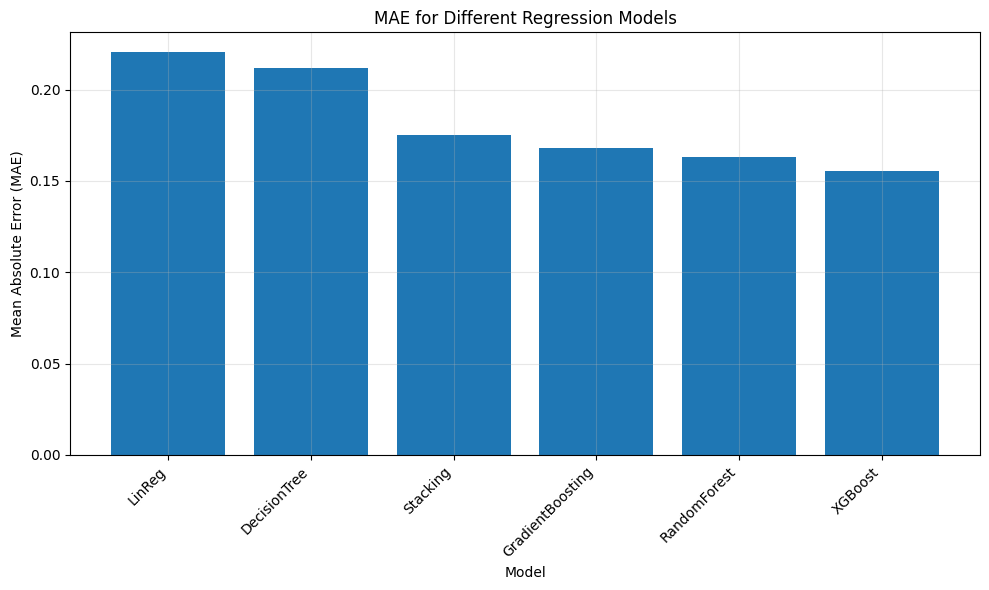

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(names, mae_list)
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("MAE for Different Regression Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(":", alpha = 0.3)
plt.show()